# Part 0 — A 2D Toy Diffusion Model

**Alejandro Lancho Serrano, Vanessa Gómez Verdejo, Pablo Martínez Olmos, Emilio Parrado Hernández**

Universidad Carlos III de Madrid

This is the gentle, visual on-ramp to the series. Everything the lecture notes describe in equations happens here in two dimensions, where we can *see* it: the forward process turning data into noise, the exact posterior we could write if we knew the clean point, a real denoiser that learns to stand in for it, the score field it implicitly learns, and finally guidance. The later notebooks (Parts 1–4) repeat these ideas on images; this one builds the intuition first.


## The one idea, before any code

A diffusion model rests on a single observation. The **forward process** that adds noise is fixed and fully known: from a clean point $x_0$ we can jump to any noise level $t$ in closed form. The **reverse process** that removes noise is the hard part, and here is why:

> The reverse step is a posterior we could write **exactly** if we knew the clean point $x_0$. A generator never knows $x_0$, so learning a diffusion model means learning to act as if we did. The best stand-in is the posterior mean $\mathbb{E}[x_0\mid x_t]$, and predicting the injected noise computes exactly that.

In 2D every piece of this is visible: the posterior with known $x_0$ (a clean Gaussian bridge), the learned reverse that replaces $x_0$ by the denoiser's guess $\hat x_0$, the score field $\nabla\log q_t$ the denoiser implicitly learns, and how a label steers the result. This maps directly onto the lecture notes: forward process, exact posterior, score perspective, and guidance.


## Notation

We use the same symbols as the lecture notes and the other notebooks:

- $x_0$ clean data, $x_t$ the noised state at level $t$, $x_T\approx\mathcal N(0,I)$.
- per-step factor $\alpha_t=1-\beta_t$, cumulative $\bar\alpha_t=\prod_{s\le t}\alpha_s$.
- forward identity $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, $\varepsilon\sim\mathcal N(0,I)$.
- exact posterior $q(x_{t-1}\mid x_t,x_0)=\mathcal N\!\big(c_1(t)x_t+c_2(t)x_0,\ \tilde\beta_t I\big)$ with posterior weights
$$c_1(t)=\frac{\sqrt{\alpha_t}\,(1-\bar\alpha_{t-1})}{1-\bar\alpha_t},\quad c_2(t)=\frac{\sqrt{\bar\alpha_{t-1}}\,\beta_t}{1-\bar\alpha_t},\quad \tilde\beta_t=\frac{1-\bar\alpha_{t-1}}{1-\bar\alpha_t}\beta_t.$$
- network $\varepsilon_\theta(x_t,t)$ predicts the noise; clean-data guess $\hat x_0=(x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon_\theta)/\sqrt{\bar\alpha_t}$.
- score $s_t(x)=\nabla_x\log q_t(x)$, related to the noise by $s_t=-\varepsilon_\theta/\sqrt{1-\bar\alpha_t}$.
- guidance: label $y$, null token $\varnothing$, classifier scale $s$, classifier-free weight $w$.


In [40]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

plt.rcParams.update({
    "figure.figsize": (6, 5),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.18, "font.size": 11,
})

# Color palette
INK="#14323B"; PETROL="#2B8A94"; PETROLD="#1E6E78"; AMBER="#B8821F"; PLUM="#6E4B6E"; ROSE="#B0506A"; SLATE="#5C6B70"
PAL = np.array([PETROL, AMBER, PLUM, ROSE])      # one colour per class

rng = np.random.default_rng(7)


## The data: four "banana" clusters

Each class is a Gaussian cloud bent by a quadratic term, rotated, and shifted, giving four curved clusters. We center the whole mixture at the origin so the forward process visibly drifts toward the unit Gaussian. Four classes let us demonstrate guidance later.


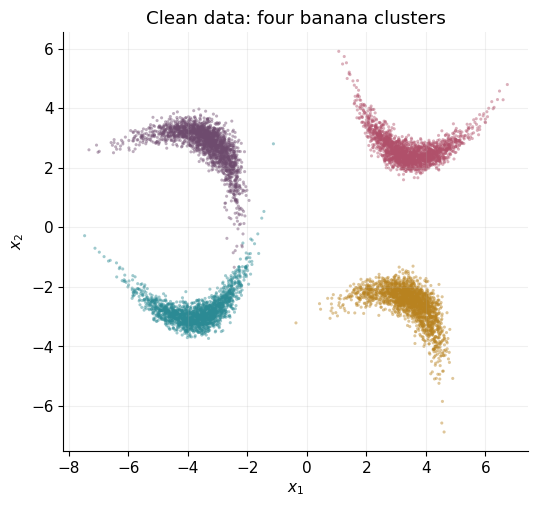

In [41]:
def rotation(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

def sample_banana(n, bend=0.35, scale=(1.0, 0.35), angle=0.0, shift=(0.0, 0.0), rng=None):
    rng = rng or np.random.default_rng()
    z = rng.normal(size=(n, 2))
    u = scale[0] * z[:, 0]
    v = scale[1] * z[:, 1] + bend * (u**2 - scale[0]**2)
    return np.column_stack([u, v]) @ rotation(angle).T + np.asarray(shift)

def sample_four_bananas(n, rng=None):
    rng = rng or np.random.default_rng()
    params = [
        dict(bend=0.38,  scale=(0.90, 0.25), angle=0.20,  shift=(-3.6, -2.7)),
        dict(bend=-0.32, scale=(0.85, 0.28), angle=-0.55, shift=( 3.5, -2.5)),
        dict(bend=0.30,  scale=(0.95, 0.27), angle=2.55,  shift=(-3.3,  2.8)),
        dict(bend=-0.36, scale=(0.90, 0.25), angle=2.95,  shift=( 3.6,  2.7)),
    ]
    labels = rng.integers(0, 4, size=n)
    x = np.empty((n, 2))
    for k, par in enumerate(params):
        idx = np.where(labels == k)[0]
        x[idx] = sample_banana(len(idx), rng=rng, **par)
    return x, labels

n_data = 8000
x_raw, labels = sample_four_bananas(n_data, rng=rng)
x0 = x_raw - x_raw.mean(axis=0)              # center the mixture

# Hold out clean points before making noisy denoising pairs.
split_rng = np.random.default_rng(123)
perm = split_rng.permutation(n_data)
n_val = int(0.2 * n_data)
val_idx, train_idx = perm[:n_val], perm[n_val:]
x0_train, labels_train = x0[train_idx], labels[train_idx]
x0_val, labels_val = x0[val_idx], labels[val_idx]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x0[:, 0], x0[:, 1], s=5, c=PAL[labels], alpha=0.45, linewidths=0)
ax.set_title("Clean data: four banana clusters"); ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_aspect("equal"); plt.show()


## The noise schedule

A fixed linear $\beta_t$ over $T=150$ steps, with $\alpha_t=1-\beta_t$ and the cumulative $\bar\alpha_t=\prod_{s\le t}\alpha_s$. By the end $\bar\alpha_T\approx 0$, so $q(x_T\mid x_0)\approx\mathcal N(0,I)$. From the schedule we also get the posterior weights $c_1,c_2,\tilde\beta_t$ used by the exact reverse step.


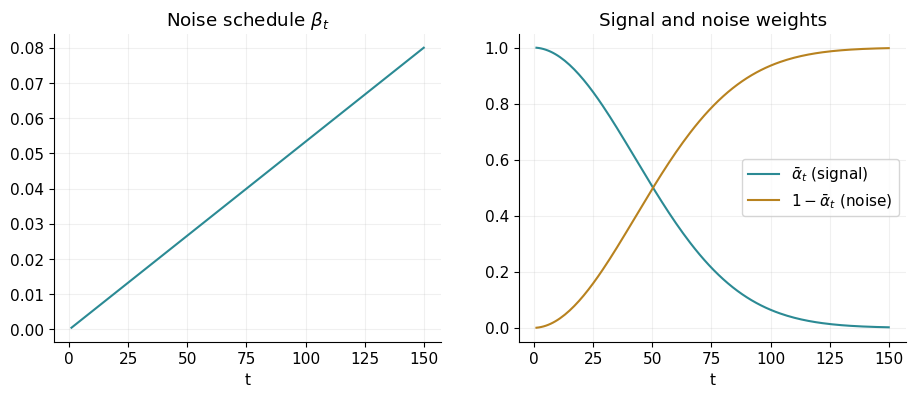

abar_T = 0.00202  ->  q(x_T|x_0) is essentially N(0, I)


In [42]:
T = 150
b_t = np.linspace(5e-4, 0.08, T)          # beta_t
a_t = 1.0 - b_t                            # alpha_t
ab_t = np.cumprod(a_t)                      # abar_t
ab_prev = np.r_[1.0, ab_t[:-1]]             # abar_{t-1}  (abar_0 = 1)

def q_sample(x0, t, rng=None, eps=None):
    rng = rng or np.random.default_rng()
    if eps is None: eps = rng.normal(size=x0.shape)
    ab = ab_t[t - 1]
    return np.sqrt(ab) * x0 + np.sqrt(1.0 - ab) * eps          # x_t = sqrt(abar) x0 + sqrt(1-abar) eps

def q_step(x_prev, t, rng=None):
    rng = rng or np.random.default_rng()
    bt = b_t[t - 1]
    return np.sqrt(1.0 - bt) * x_prev + np.sqrt(bt) * rng.normal(size=x_prev.shape)

def posterior_coefficients(t):
    bt, ab, abp = b_t[t - 1], ab_t[t - 1], ab_prev[t - 1]
    denom = 1.0 - ab
    c1 = np.sqrt(1.0 - bt) * (1.0 - abp) / denom               # weight on current x_t
    c2 = np.sqrt(abp) * bt / denom                              # weight on clean x_0
    var = bt * (1.0 - abp) / denom                              # posterior variance beta_tilde_t
    return c1, c2, var

def q_posterior_sample(x_t, x0, t, rng=None):
    rng = rng or np.random.default_rng()
    c1, c2, var = posterior_coefficients(t)
    mean = c1 * x_t + c2 * x0
    return mean if t == 1 else mean + np.sqrt(var) * rng.normal(size=mean.shape)

ts = np.arange(1, T + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts, b_t, color=PETROL); axes[0].set_title(r"Noise schedule $\beta_t$"); axes[0].set_xlabel("t")
axes[1].plot(ts, ab_t, color=PETROL, label=r"$\bar\alpha_t$ (signal)")
axes[1].plot(ts, 1 - ab_t, color=AMBER, label=r"$1-\bar\alpha_t$ (noise)")
axes[1].set_title("Signal and noise weights"); axes[1].set_xlabel("t"); axes[1].legend()
plt.show()
print(f"abar_T = {ab_t[-1]:.5f}  ->  q(x_T|x_0) is essentially N(0, I)")


## Forward marginals: data dissolving into noise

For each clean point, $q(x_t\mid x_0)=\mathcal N(\sqrt{\bar\alpha_t}x_0,\,(1-\bar\alpha_t)I)$ shrinks the signal and adds isotropic noise. Watch the four clusters melt into one Gaussian blob.


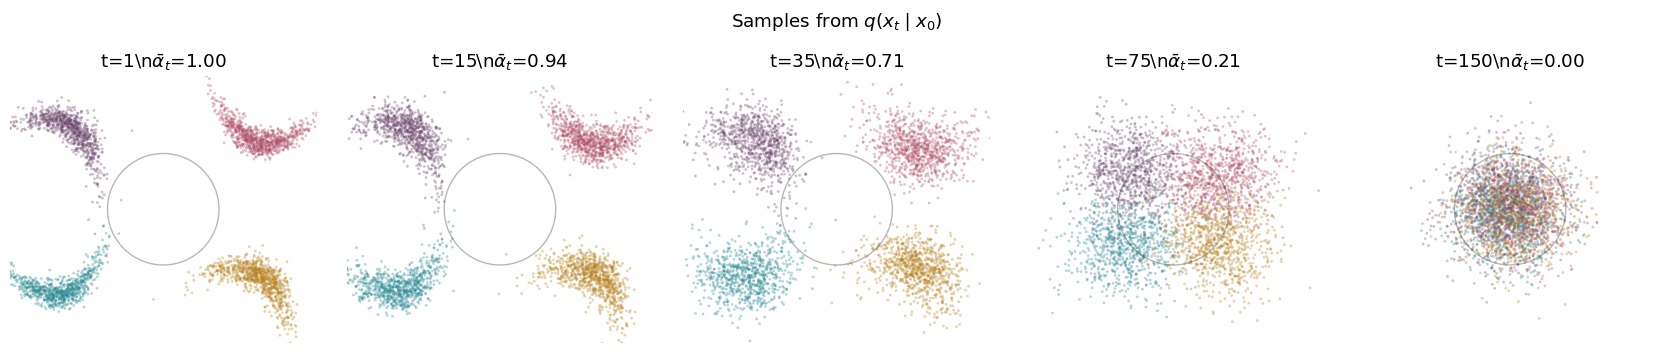

In [43]:
def plot_marginals(times=(1, 15, 35, 75, 150), n=3500):
    idx = rng.choice(len(x0), size=n, replace=False)
    fig, axes = plt.subplots(1, len(times), figsize=(3.4 * len(times), 3.4), sharex=True, sharey=True)
    for ax, t in zip(axes, times):
        xt = q_sample(x0[idx], t, rng)
        ax.scatter(xt[:, 0], xt[:, 1], s=4, c=PAL[labels[idx]], alpha=0.35, linewidths=0)
        ax.add_patch(plt.Circle((0, 0), 2.0, color="0.3", fill=False, lw=1, alpha=0.4))
        ax.set_title(f"t={t}\\n" + r"$\bar\alpha_t$=" + f"{ab_t[t-1]:.2f}")
        ax.set_aspect("equal"); ax.set_xlim(-5.5, 5.5); ax.set_ylim(-4.8, 4.8); ax.axis("off")
    fig.suptitle(r"Samples from $q(x_t\mid x_0)$", y=1.03); plt.tight_layout(); plt.show()

plot_marginals()


## Forward trajectories

The same process step by step: each thin line is one realization of $x_t=\sqrt{\alpha_t}\,x_{t-1}+\sqrt{\beta_t}\,\varepsilon_t$, with fresh noise at every step. The paths wander out from the clusters and end near the origin.


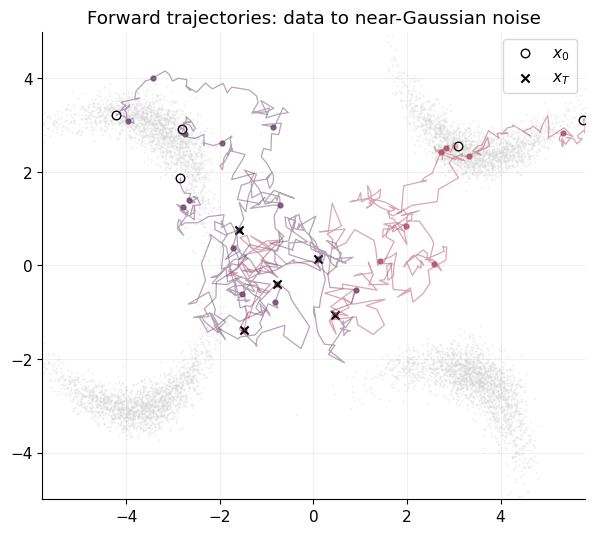

In [44]:
def simulate_forward_paths(x0_start, rng=None):
    rng = rng or np.random.default_rng()
    path = np.empty((T + 1, *x0_start.shape)); path[0] = x0_start
    for t in range(1, T + 1):
        path[t] = q_step(path[t - 1], t, rng)
    return path

n_paths = 5
start_idx = rng.choice(len(x0), size=n_paths, replace=False)
paths = simulate_forward_paths(x0[start_idx], rng=rng)
snap = np.array([0, 10, 30, 60, 100, 150])

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.82", alpha=0.35, linewidths=0)
for j in range(n_paths):
    col = PAL[labels[start_idx[j]]]
    ax.plot(paths[:, j, 0], paths[:, j, 1], color=col, lw=0.9, alpha=0.5)
    ax.scatter(paths[snap, j, 0], paths[snap, j, 1], color=col, s=12, alpha=0.85)
ax.scatter(paths[0, :, 0], paths[0, :, 1], marker="o", s=38, facecolor="white", edgecolor="k", label="$x_0$")
ax.scatter(paths[-1, :, 0], paths[-1, :, 1], marker="x", s=35, color="k", label="$x_T$")
ax.set_title("Forward trajectories: data to near-Gaussian noise")
ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.legend(loc="upper right"); plt.show()


## One noisy point, many clean explanations

Fix a single clean $x_0$ and draw many $x_t$ from $q(x_t\mid x_0)$: an isotropic cloud around $\sqrt{\bar\alpha_t}x_0$. Read backwards, this is the difficulty of generation: a given noisy point could have come from many clean points, so the reverse step is a *distribution*, not a single answer.


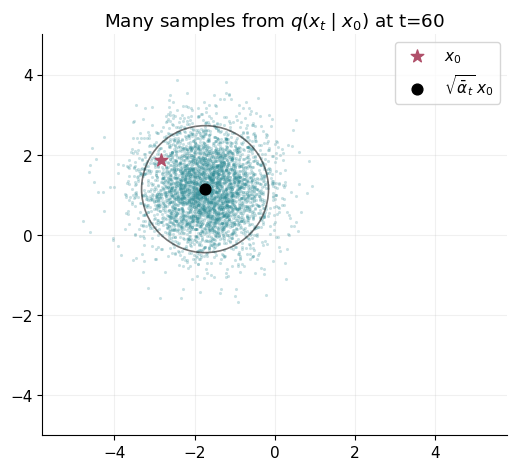

In [45]:
def plot_single_point_marginal(point_index=0, t=60, n=4000):
    clean = x0[point_index]
    xt = q_sample(np.repeat(clean[None, :], n, axis=0), t, eps=rng.normal(size=(n, 2)))
    center = np.sqrt(ab_t[t - 1]) * clean
    radius = 2.0 * np.sqrt(1.0 - ab_t[t - 1])
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(xt[:, 0], xt[:, 1], s=5, alpha=0.25, color=PETROL, linewidths=0)
    ax.scatter(*clean, s=90, marker="*", color=ROSE, label="$x_0$", zorder=5)
    ax.scatter(*center, s=60, color="k", label=r"$\sqrt{\bar\alpha_t}\,x_0$")
    ax.add_patch(plt.Circle(center, radius, fill=False, color="k", lw=1.2, alpha=0.55))
    ax.set_title(fr"Many samples from $q(x_t\mid x_0)$ at t={t}")
    ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.legend(); plt.show()

plot_single_point_marginal(point_index=int(start_idx[0]), t=60)
if HAS_WIDGETS:
    display(widgets.interact(plot_single_point_marginal,
        point_index=widgets.IntSlider(value=int(start_idx[0]), min=0, max=len(x0)-1, step=1),
        t=widgets.IntSlider(value=60, min=1, max=T, step=1),
        n=widgets.IntSlider(value=2500, min=500, max=8000, step=500)))


## The exact posterior: if we knew $x_0$

Condition on *both* the noisy point $x_t$ and its clean origin $x_0$. Then the reverse step is an exact Gaussian, $q(x_{t-1}\mid x_t,x_0)=\mathcal N(c_1(t)x_t+c_2(t)x_0,\ \tilde\beta_t I)$. Below, many posterior paths from the same $x_T$ all funnel back to the known $x_0$ (red star). This is the reverse process we *wish* we had; the only thing missing in reality is $x_0$.


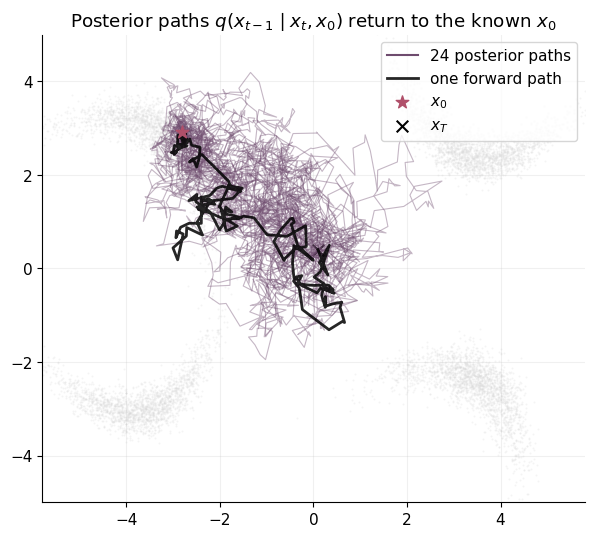

In [46]:
def posterior_path_from_endpoint(xT, x0_clean, rng=None):
    rng = rng or np.random.default_rng()
    path = np.empty((T + 1, 2)); path[T] = xT
    for t in range(T, 0, -1):
        path[t - 1] = q_posterior_sample(path[t], x0_clean, t, rng)
    return path

def compare_forward_and_posterior_path(point_index=None, n_posterior_paths=24):
    point_index = int(start_idx[1]) if point_index is None else int(point_index)
    clean = x0[point_index]
    forward = simulate_forward_paths(clean[None, :], rng=rng)[:, 0, :]
    endpoint = forward[-1]
    post = np.stack([posterior_path_from_endpoint(endpoint, clean, rng=rng) for _ in range(int(n_posterior_paths))])
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.84", alpha=0.25, linewidths=0)
    for p in post: ax.plot(p[:, 0], p[:, 1], color=PLUM, lw=0.8, alpha=0.4)
    ax.plot([], [], color=PLUM, lw=1.5, label=f"{int(n_posterior_paths)} posterior paths")
    ax.plot(forward[:, 0], forward[:, 1], color="k", lw=2, alpha=0.85, label="one forward path")
    ax.scatter(*clean, s=90, marker="*", color=ROSE, label="$x_0$", zorder=5)
    ax.scatter(*endpoint, s=70, marker="x", color="k", label="$x_T$")
    ax.set_title(r"Posterior paths $q(x_{t-1}\mid x_t,x_0)$ return to the known $x_0$")
    ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.legend(loc="upper right"); plt.show()

compare_forward_and_posterior_path(n_posterior_paths=24)
if HAS_WIDGETS:
    display(widgets.interact(compare_forward_and_posterior_path,
        point_index=widgets.IntSlider(value=int(start_idx[1]), min=0, max=len(x0)-1, step=1),
        n_posterior_paths=widgets.IntSlider(value=24, min=1, max=100, step=1)))


## Posterior weights: handing trust from $x_t$ to $x_0$

The posterior mean is a blend $c_1(t)x_t+c_2(t)x_0$. The weights are fixed by the schedule and tell a clean story: at high noise the step leans on the current state ($c_1$ large), and near the clean end it commits to the target ($c_2\to1$ at $t=1$). The reverse process is learning how much to commit at each level.


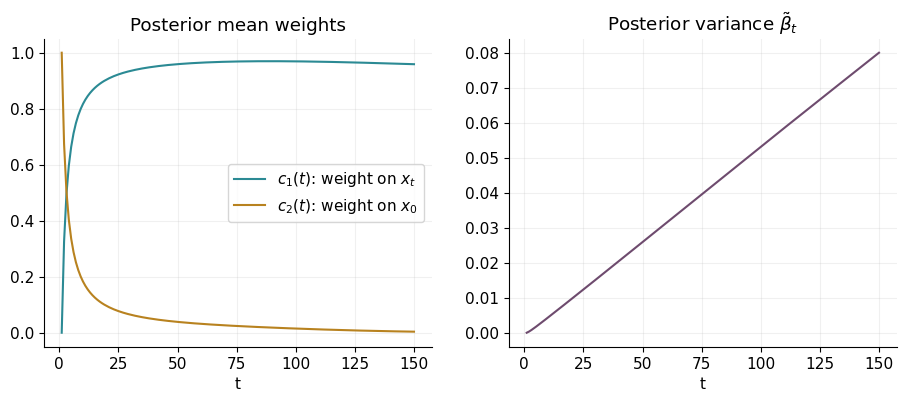

t=  1: c1= 0.000  c2= 1.000  beta_tilde= 0.0000
t=  5: c1= 0.664  c2= 0.336  beta_tilde= 0.0018
t= 15: c1= 0.874  c2= 0.126  beta_tilde= 0.0070
t= 40: c1= 0.950  c2= 0.049  beta_tilde= 0.0205
t= 80: c1= 0.969  c2= 0.022  beta_tilde= 0.0423
t=150: c1= 0.959  c2= 0.004  beta_tilde= 0.0800


In [47]:
c1v, c2v, varv = (np.empty(T) for _ in range(3))
for t in range(1, T + 1):
    c1v[t-1], c2v[t-1], varv[t-1] = posterior_coefficients(t)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ts, c1v, color=PETROL, label=r"$c_1(t)$: weight on $x_t$")
axes[0].plot(ts, c2v, color=AMBER,  label=r"$c_2(t)$: weight on $x_0$")
axes[0].set_xlabel("t"); axes[0].set_title("Posterior mean weights"); axes[0].legend()
axes[1].plot(ts, varv, color=PLUM); axes[1].set_xlabel("t"); axes[1].set_title(r"Posterior variance $\tilde\beta_t$")
plt.show()
for t in [1, 5, 15, 40, 80, 150]:
    c1, c2, var = posterior_coefficients(t)
    print(f"t={t:3d}: c1={c1: .3f}  c2={c2: .3f}  beta_tilde={var: .4f}")


## The score field $\nabla\log q_t(x)$

The reverse process can also be read through the **score** $s_t(x)=\nabla_x\log q_t(x)$: the direction in which the noised density increases. By Tweedie's identity it is exactly the direction toward more probable (cleaner) data, and it is tied to the noise by $s_t=-\varepsilon_\theta/\sqrt{1-\bar\alpha_t}$ — so predicting noise *is* estimating the score.

We can compute it in closed form here by approximating each banana with a Gaussian (mean and covariance per class). The noised mixture stays Gaussian per component, so the score is exact. Notice how, at low noise, the field points into the four basins; as noise grows the basins merge and everything points toward the origin, the score of $\mathcal N(0,I)$.


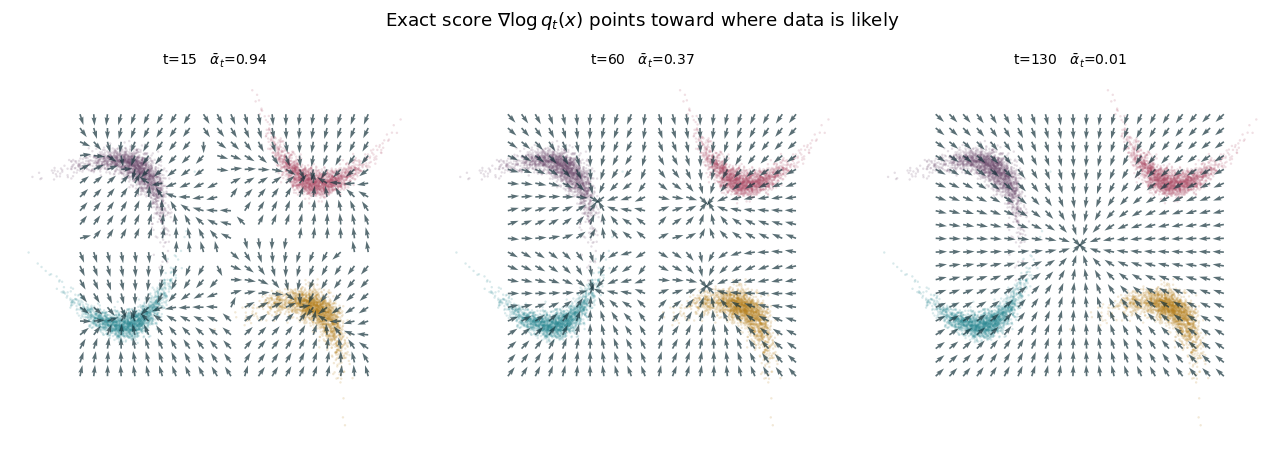

In [48]:
# Gaussian-mixture approximation (one Gaussian per class) -> closed-form score of q_t
mus  = np.stack([x0[labels == k].mean(0) for k in range(4)])
covs = np.stack([np.cov(x0[labels == k].T) for k in range(4)])
pis  = np.array([(labels == k).mean() for k in range(4)])

def score_exact(X, t):
    # exact grad-log of q_t(x) for the per-class Gaussian mixture (closed form)
    ab = ab_t[t - 1]
    cmu = np.sqrt(ab) * mus
    cS  = ab * covs + (1.0 - ab) * np.eye(2)[None]
    N = X.shape[0]; logN = np.empty((N, 4)); grads = np.empty((N, 4, 2))
    for k in range(4):
        Si = np.linalg.inv(cS[k]); d = X - cmu[k]
        logN[:, k] = np.log(pis[k]) - 0.5*(np.einsum('ni,ij,nj->n', d, Si, d) + np.log(np.linalg.det(cS[k])) + 2*np.log(2*np.pi))
        grads[:, k, :] = -(d @ Si.T)
    w = np.exp(logN - logN.max(1, keepdims=True)); w /= w.sum(1, keepdims=True)
    return np.einsum('nk,nki->ni', w, grads)

gx, gy = np.meshgrid(np.linspace(-5.5, 5.5, 22), np.linspace(-5, 5, 20))
grid = np.column_stack([gx.ravel(), gy.ravel()])
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharex=True, sharey=True)
for ax, t in zip(axes, [15, 60, 130]):
    s = score_exact(grid, t); sdir = s / (np.linalg.norm(s, axis=1, keepdims=True) + 1e-8) * 0.5
    ax.scatter(x0[:, 0], x0[:, 1], s=3, c=PAL[labels], alpha=0.18, linewidths=0)
    ax.quiver(grid[:, 0], grid[:, 1], sdir[:, 0], sdir[:, 1], color=INK, alpha=0.7, width=0.004, scale=18)
    ax.set_title(f"t={t}   " + r"$\bar\alpha_t$=" + f"{ab_t[t-1]:.2f}", fontsize=10)
    ax.set_aspect("equal"); ax.axis("off")
fig.suptitle(r"Exact score $\nabla\log q_t(x)$ points toward where data is likely", y=1.02)
plt.tight_layout(); plt.show()


## A first learned denoiser

Now the real thing: a small MLP that takes a noisy point $x_t$ and the time $t$ and predicts the injected noise $\varepsilon_\theta(x_t,t)$. We train it on noisy versions of the training clean points, and validate on noisy versions of held-out clean points. From the prediction we recover the clean-data guess
$$\hat x_0=\frac{x_t-\sqrt{1-\bar\alpha_t}\,\varepsilon_\theta(x_t,t)}{\sqrt{\bar\alpha_t}}.$$
This is the missing-$x_0$ stand-in. The network is deliberately tiny; the point is the idea, not the architecture.


Using device: cpu
epoch 01 | train 0.6427 | val 0.5482
epoch 05 | train 0.4377 | val 0.4502
epoch 10 | train 0.4243 | val 0.4397
epoch 15 | train 0.4193 | val 0.4381
epoch 20 | train 0.4137 | val 0.4306
epoch 25 | train 0.4124 | val 0.4308
epoch 30 | train 0.4092 | val 0.4276
epoch 35 | train 0.4078 | val 0.4248


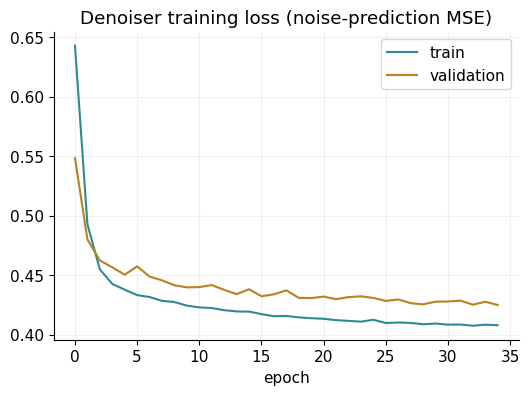

In [49]:
import importlib.util
if importlib.util.find_spec("torch") is None:
    raise ImportError("PyTorch is required from here on. Install it (e.g. `pip install torch`) and rerun from this cell.")

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
torch.manual_seed(3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def make_denoising_dataset(clean_points, n_samples=45000, rng=None):
    rng = rng or np.random.default_rng()
    idx = rng.integers(0, len(clean_points), size=n_samples)
    t = rng.integers(1, T + 1, size=n_samples)
    clean = clean_points[idx]; eps = rng.normal(size=clean.shape)
    sqrt_ab = np.sqrt(ab_t[t - 1]); sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])
    xt = sqrt_ab[:, None] * clean + sqrt_1mab[:, None] * eps
    feats = np.column_stack([xt, t / T, sqrt_ab, sqrt_1mab])     # [x_t, t/T, sqrt(abar), sqrt(1-abar)]
    return feats, eps

X_train, eps_train = make_denoising_dataset(x0_train, 45000, rng)
X_val, eps_val = make_denoising_dataset(x0_val, 8000, rng)
feat_mean = torch.tensor(X_train.mean(0), dtype=torch.float32, device=device)
feat_std  = torch.tensor(X_train.std(0) + 1e-6, dtype=torch.float32, device=device)
def standardize(x): return (x - feat_mean) / feat_std

loader = DataLoader(TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                  torch.tensor(eps_train, dtype=torch.float32)), batch_size=512, shuffle=True)
Xv = torch.tensor(X_val, dtype=torch.float32, device=device); epsv = torch.tensor(eps_val, dtype=torch.float32, device=device)

class DenoiserMLP(nn.Module):
    def __init__(self, d_in=5, h=128, d_out=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d_out))
    def forward(self, x): return self.net(x)

denoiser = DenoiserMLP().to(device)
opt = torch.optim.AdamW(denoiser.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()
tr, va = [], []
for epoch in range(1, 36):
    denoiser.train()
    el = []
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(denoiser(standardize(xb)), yb)
        opt.zero_grad(); loss.backward(); opt.step(); el.append(loss.item())
    denoiser.eval()
    with torch.no_grad(): vl = loss_fn(denoiser(standardize(Xv)), epsv).item()
    tr.append(float(np.mean(el))); va.append(vl)
    if epoch == 1 or epoch % 5 == 0: print(f"epoch {epoch:02d} | train {tr[-1]:.4f} | val {vl:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(tr, color=PETROL, label="train"); ax.plot(va, color=AMBER, label="validation")
ax.set_title("Denoiser training loss (noise-prediction MSE)"); ax.set_xlabel("epoch"); ax.legend(); plt.show()


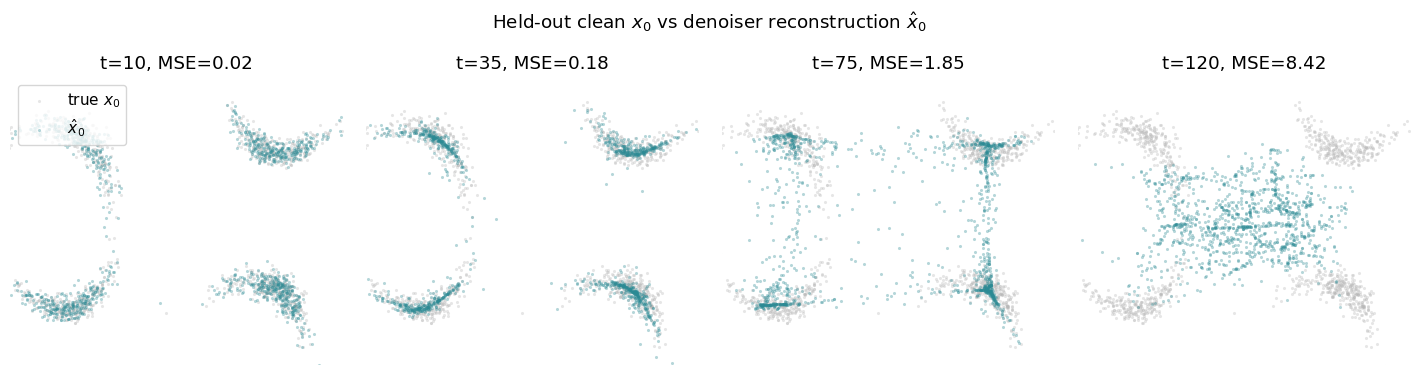

In [50]:
def denoiser_predict_eps(xt, t):
    t = np.asarray(t)
    if t.ndim == 0: t = np.full(len(xt), int(t))
    sqrt_ab = np.sqrt(ab_t[t - 1]); sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])
    feats = np.column_stack([xt, t / T, sqrt_ab, sqrt_1mab])
    denoiser.eval()
    with torch.no_grad():
        eps_hat = denoiser(standardize(torch.tensor(feats, dtype=torch.float32, device=device)))
    return eps_hat.cpu().numpy()

def reconstruct_x0(xt, t):
    t = np.asarray(t)
    if t.ndim == 0: t = np.full(len(xt), int(t))
    sqrt_ab = np.sqrt(ab_t[t - 1])[:, None]; sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])[:, None]
    return (xt - sqrt_1mab * denoiser_predict_eps(xt, t)) / sqrt_ab

def plot_x0_reconstruction(times=(10, 35, 75, 120), n=1200):
    n = min(int(n), len(x0_val))
    idx = rng.choice(len(x0_val), size=n, replace=False); clean = x0_val[idx]
    fig, axes = plt.subplots(1, len(times), figsize=(3.6 * len(times), 3.6), sharex=True, sharey=True)
    for ax, t in zip(axes, times):
        xt = q_sample(clean, t, eps=rng.normal(size=clean.shape))
        x0_hat = reconstruct_x0(xt, t); mse = np.mean((x0_hat - clean) ** 2)
        ax.scatter(clean[:, 0], clean[:, 1], s=5, color="0.72", alpha=0.35, linewidths=0, label="true $x_0$")
        ax.scatter(x0_hat[:, 0], x0_hat[:, 1], s=5, color=PETROL, alpha=0.35, linewidths=0, label=r"$\hat x_0$")
        ax.set_title(f"t={t}, MSE={mse:.2f}"); ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.axis("off")
    axes[0].legend(loc="upper left"); fig.suptitle(r"Held-out clean $x_0$ vs denoiser reconstruction $\hat x_0$", y=1.03)
    plt.tight_layout(); plt.show()

plot_x0_reconstruction()


## Score = noise: what the network learned

The trained denoiser gives us the score for free, via $s_t(x)=-\varepsilon_\theta(x,t)/\sqrt{1-\bar\alpha_t}$. Below, the network's score (petrol) is laid over the exact closed-form score (grey) at one noise level: predicting the noise and estimating the score are the same task in different coordinates.


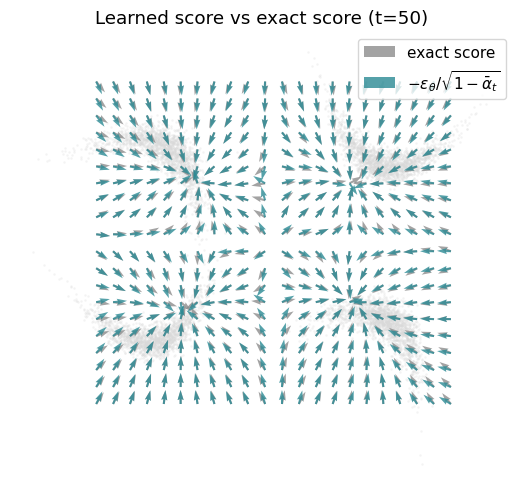

In [51]:
t_show = 50
s_exact = score_exact(grid, t_show)
s_learn = -denoiser_predict_eps(grid, t_show) / np.sqrt(1.0 - ab_t[t_show - 1])
def unit(v): return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-8) * 0.5
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(x0[:, 0], x0[:, 1], s=3, color="0.85", alpha=0.3, linewidths=0)
ue, ul = unit(s_exact), unit(s_learn)
ax.quiver(grid[:, 0], grid[:, 1], ue[:, 0], ue[:, 1], color="0.55", alpha=0.8, width=0.004, scale=18, label="exact score")
ax.quiver(grid[:, 0], grid[:, 1], ul[:, 0], ul[:, 1], color=PETROL, alpha=0.8, width=0.004, scale=18, label=r"$-\varepsilon_\theta/\sqrt{1-\bar\alpha_t}$")
ax.set_title(f"Learned score vs exact score (t={t_show})"); ax.set_aspect("equal"); ax.axis("off"); ax.legend(loc="upper right"); plt.show()


## Learned reverse trajectories

Now run the reverse chain for real. Replace the unknown $x_0$ in the posterior mean by the denoiser's guess $\hat x_0(x_t,t)$:
$$\mu_\theta(x_t,t)=c_1(t)x_t+c_2(t)\hat x_0(x_t,t),\qquad x_{t-1}\sim\mathcal N(\mu_\theta,\tilde\beta_t I).$$
Starting from pure noise, the paths climb the score field back onto the clusters.


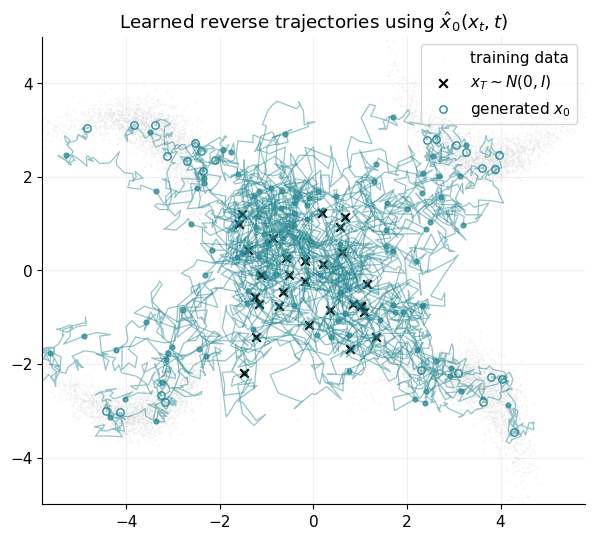

In [52]:
def learned_reverse_step(x_t, t, rng=None, add_noise=True):
    rng = rng or np.random.default_rng()
    x0_hat = reconstruct_x0(x_t, t)
    c1, c2, var = posterior_coefficients(t)
    mean = c1 * x_t + c2 * x0_hat
    if t == 1 or not add_noise: return mean, x0_hat
    return mean + np.sqrt(var) * rng.normal(size=x_t.shape), x0_hat

def learned_reverse_chain(n_samples=1000, keep_trajectory=False, rng=None, xT_initial=None):
    rng = rng or np.random.default_rng()
    x_t = rng.normal(size=(n_samples, 2)) if xT_initial is None else np.asarray(xT_initial, float)
    if x_t.ndim == 1: x_t = np.repeat(x_t[None, :], n_samples, axis=0)
    n_samples = len(x_t)
    if keep_trajectory:
        traj = np.empty((T + 1, n_samples, 2)); traj[T] = x_t
    for t in range(T, 0, -1):
        x_t, _ = learned_reverse_step(x_t, t, rng=rng, add_noise=True)
        if keep_trajectory: traj[t - 1] = x_t
    return (x_t, traj) if keep_trajectory else x_t

def plot_learned_reverse_trajectories(n_paths=28):
    samples, traj = learned_reverse_chain(n_samples=int(n_paths), keep_trajectory=True, rng=rng)
    snap = np.array([T, 120, 90, 60, 30, 0])
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.84", alpha=0.25, linewidths=0, label="training data")
    for j in range(int(n_paths)):
        p = traj[:, j, :]
        ax.plot(p[:, 0], p[:, 1], color=PETROL, lw=0.9, alpha=0.5)
        ax.scatter(p[snap, 0], p[snap, 1], color=PETROL, s=12, alpha=0.75)
    ax.scatter(traj[T, :, 0], traj[T, :, 1], marker="x", s=38, color="k", label=r"$x_T\sim N(0,I)$")
    ax.scatter(samples[:, 0], samples[:, 1], marker="o", s=28, facecolor="white", edgecolor=PETROL, label="generated $x_0$")
    ax.set_title(r"Learned reverse trajectories using $\hat x_0(x_t,t)$")
    ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.legend(loc="upper right"); plt.show()

plot_learned_reverse_trajectories(n_paths=28)
if HAS_WIDGETS:
    display(widgets.interact(plot_learned_reverse_trajectories,
        n_paths=widgets.IntSlider(value=28, min=4, max=80, step=4)))


## Exact bridge vs learned reverse

From the *same* $x_T$, compare the exact posterior paths (which secretly know the true $x_0$, left) with the learned reverse paths (which only have $\hat x_0$ from the denoiser, right). The exact bridge is conditioned on the red star, so it must return there. The learned reverse chain is not conditioned on that star: at high noise, the same $x_T$ can be compatible with several clean explanations. Its job is to land on the learned data distribution, not necessarily on the original clean point. The white circles on the right mark the final learned $x_0$ samples, which may choose another cluster.


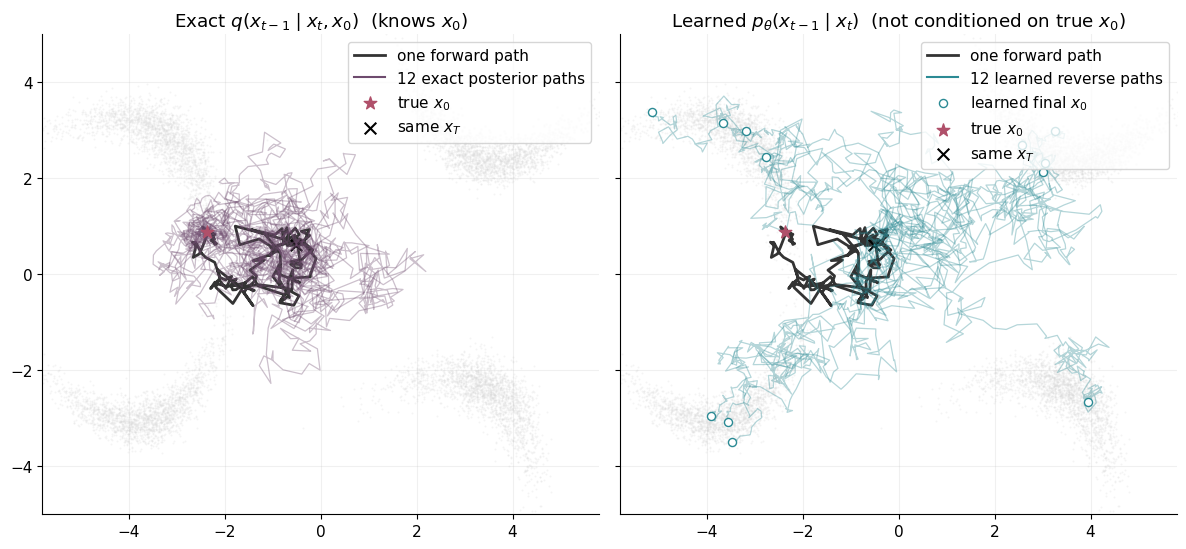

In [53]:
def plot_exact_bridge_vs_learned_reverse(point_index=None, n_exact_paths=12, n_learned_paths=12):
    point_index = int(start_idx[2]) if point_index is None else int(point_index)
    clean = x0[point_index]
    forward = simulate_forward_paths(clean[None, :], rng=rng)[:, 0, :]; endpoint = forward[-1]
    exact = np.stack([posterior_path_from_endpoint(endpoint, clean, rng=rng) for _ in range(int(n_exact_paths))])
    _, learned = learned_reverse_chain(n_samples=int(n_learned_paths), keep_trajectory=True, rng=rng,
                                       xT_initial=np.repeat(endpoint[None, :], int(n_learned_paths), axis=0))
    learned_paths = np.moveaxis(learned, 1, 0)
    learned_final = learned[0]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), sharex=True, sharey=True)
    panels = [(axes[0], exact, PLUM, f"{int(n_exact_paths)} exact posterior paths"),
              (axes[1], learned_paths, PETROL, f"{int(n_learned_paths)} learned reverse paths")]
    for ax, paths, color, label in panels:
        ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.84", alpha=0.25, linewidths=0)
        ax.plot(forward[:, 0], forward[:, 1], color="k", lw=2, alpha=0.8, label="one forward path")
        for p in paths: ax.plot(p[:, 0], p[:, 1], color=color, lw=0.9, alpha=0.35)
        ax.plot([], [], color=color, lw=1.5, label=label)
        if ax is axes[1]:
            ax.scatter(learned_final[:, 0], learned_final[:, 1], s=34, marker="o",
                       facecolor="white", edgecolor=color, linewidths=1.0,
                       label="learned final $x_0$", zorder=4)
        ax.scatter(*clean, s=90, marker="*", color=ROSE, label="true $x_0$", zorder=5)
        ax.scatter(*endpoint, s=70, marker="x", color="k", label="same $x_T$")
        ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.legend(loc="upper right")
    axes[0].set_title(r"Exact $q(x_{t-1}\mid x_t,x_0)$  (knows $x_0$)")
    axes[1].set_title(r"Learned $p_\theta(x_{t-1}\mid x_t)$  (not conditioned on true $x_0$)")
    plt.tight_layout(); plt.show()

plot_exact_bridge_vs_learned_reverse(point_index=100, n_exact_paths=12, n_learned_paths=12)
if HAS_WIDGETS:
    display(widgets.interact(plot_exact_bridge_vs_learned_reverse,
        point_index=widgets.IntSlider(value=int(start_idx[2]), min=0, max=len(x0)-1, step=1),
        n_exact_paths=widgets.IntSlider(value=12, min=1, max=60, step=1),
        n_learned_paths=widgets.IntSlider(value=12, min=1, max=60, step=1)))


## Generated samples

Draw many $x_T\sim\mathcal N(0,I)$, run the learned reverse chain, and compare with the data. Unconditional generation reproduces all four clusters.


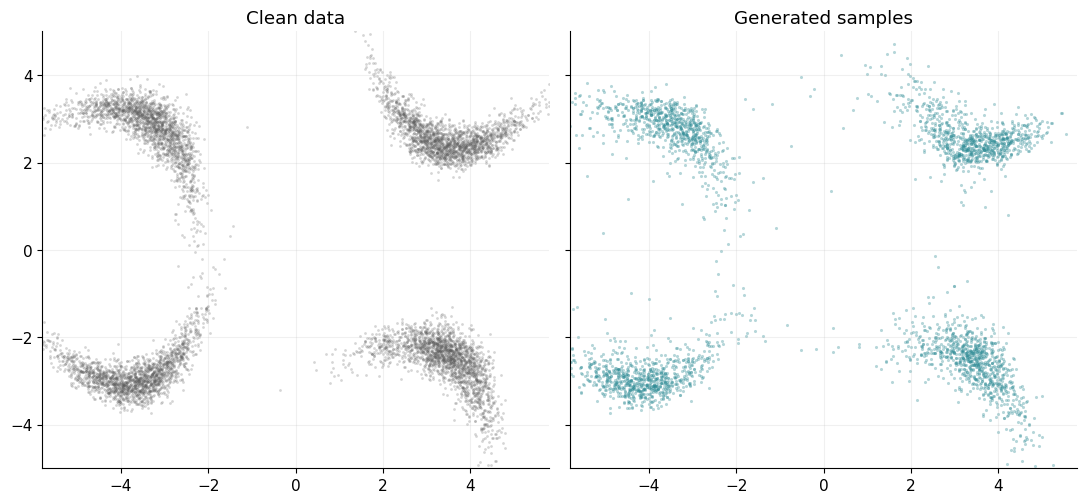

In [54]:
generated = learned_reverse_chain(n_samples=3500, keep_trajectory=False, rng=rng)
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)
axes[0].scatter(x0[:, 0], x0[:, 1], s=4, color="0.35", alpha=0.25, linewidths=0); axes[0].set_title("Clean data")
axes[1].scatter(generated[:, 0], generated[:, 1], s=5, color=PETROL, alpha=0.35, linewidths=0); axes[1].set_title("Generated samples")
for ax in axes: ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5)
plt.tight_layout(); plt.show()


## Classifier guidance

To steer generation toward a class $y$, train a separate classifier $p_\phi(y\mid x_t,t)$ on *noisy* points and push each reverse step uphill in the log-probability of the target class:
$$\mu_{\mathrm{guided}}(x_t,t,y)=\mu_\theta(x_t,t)+s\,\tilde\beta_t\,\nabla_{x_t}\log p_\phi(y\mid x_t,t).$$
The scale $s$ controls strength: larger $s$ forces the chosen cluster harder, at the cost of diversity.


In [55]:
def make_labeled_dataset(clean_points, clean_labels, n_samples=45000, rng=None):
    rng = rng or np.random.default_rng()
    idx = rng.integers(0, len(clean_points), size=n_samples); t = rng.integers(1, T + 1, size=n_samples)
    clean = clean_points[idx]; y = clean_labels[idx]; eps = rng.normal(size=clean.shape)
    sqrt_ab = np.sqrt(ab_t[t - 1]); sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])
    xt = sqrt_ab[:, None] * clean + sqrt_1mab[:, None] * eps
    return np.column_stack([xt, t / T, sqrt_ab, sqrt_1mab]), y

Xc, yc = make_labeled_dataset(x0_train, labels_train, 45000, rng)
Xc_val, yc_val = make_labeled_dataset(x0_val, labels_val, 8000, rng)
cf_mean = torch.tensor(Xc.mean(0), dtype=torch.float32, device=device)
cf_std  = torch.tensor(Xc.std(0) + 1e-6, dtype=torch.float32, device=device)
def std_clf(x): return (x - cf_mean) / cf_std

class ClassifierMLP(nn.Module):
    def __init__(self, d_in=5, h=128, n_cls=4):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, n_cls))
    def forward(self, x): return self.net(x)

classifier = ClassifierMLP().to(device)
copt = torch.optim.AdamW(classifier.parameters(), lr=1e-3, weight_decay=1e-5)
celoss = nn.CrossEntropyLoss()
cloader = DataLoader(TensorDataset(torch.tensor(Xc, dtype=torch.float32), torch.tensor(yc, dtype=torch.long)),
                     batch_size=512, shuffle=True)
for epoch in range(1, 26):
    classifier.train()
    for xb, yb in cloader:
        xb, yb = xb.to(device), yb.to(device)
        loss = celoss(classifier(std_clf(xb)), yb)
        copt.zero_grad(); loss.backward(); copt.step()
    if epoch == 1 or epoch % 5 == 0:
        classifier.eval()
        with torch.no_grad():
            acc = (classifier(std_clf(torch.tensor(Xc_val, dtype=torch.float32, device=device))).argmax(1)
                   == torch.tensor(yc_val, device=device)).float().mean().item()
        print(f"classifier epoch {epoch:02d} | held-out acc {acc:.3f}")


classifier epoch 01 | held-out acc 0.744
classifier epoch 05 | held-out acc 0.742
classifier epoch 10 | held-out acc 0.744
classifier epoch 15 | held-out acc 0.743
classifier epoch 20 | held-out acc 0.745
classifier epoch 25 | held-out acc 0.744


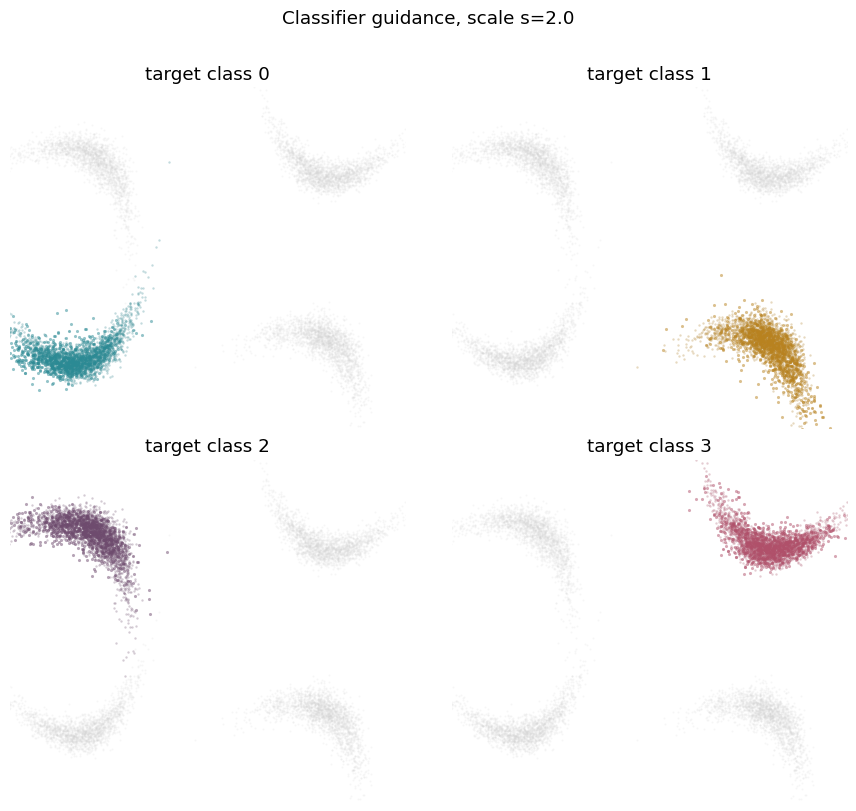

In [56]:
def classifier_grad(x_t, t, target):
    xt = torch.tensor(x_t, dtype=torch.float32, device=device, requires_grad=True)
    n = xt.shape[0]
    sqrt_ab = torch.full((n,), float(np.sqrt(ab_t[t - 1])), device=device)
    sqrt_1mab = torch.full((n,), float(np.sqrt(1.0 - ab_t[t - 1])), device=device)
    feats = torch.column_stack([xt, torch.full((n,), t / T, device=device), sqrt_ab, sqrt_1mab])
    logp = torch.log_softmax(classifier(std_clf(feats)), dim=1)[:, int(target)].sum()
    return torch.autograd.grad(logp, xt)[0].detach().cpu().numpy()

def classifier_guided_chain(n_samples=900, target=0, scale=2.0, rng=None):
    rng = rng or np.random.default_rng()
    x_t = rng.normal(size=(n_samples, 2))
    for t in range(T, 0, -1):
        x0_hat = reconstruct_x0(x_t, t); c1, c2, var = posterior_coefficients(t)
        mean = c1 * x_t + c2 * x0_hat + scale * var * classifier_grad(x_t, t, target)
        x_t = mean if t == 1 else mean + np.sqrt(var) * rng.normal(size=x_t.shape)
    return x_t

def plot_classifier_guided(n_per_class=900, scale=2.0):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True); axes = axes.ravel()
    for y, ax in enumerate(axes):
        g = classifier_guided_chain(int(n_per_class), target=y, scale=scale, rng=rng)
        ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.82", alpha=0.18, linewidths=0)
        ax.scatter(x0[labels == y, 0], x0[labels == y, 1], s=3, color=PAL[y], alpha=0.25, linewidths=0)
        ax.scatter(g[:, 0], g[:, 1], s=5, color=PAL[y], alpha=0.5, linewidths=0)
        ax.set_title(f"target class {y}"); ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.axis("off")
    fig.suptitle(f"Classifier guidance, scale s={scale}", y=1.01); plt.tight_layout(); plt.show()

plot_classifier_guided(scale=2.0)
if HAS_WIDGETS:
    display(widgets.interact(plot_classifier_guided,
        n_per_class=widgets.IntSlider(value=900, min=200, max=2000, step=100),
        scale=widgets.FloatSlider(value=2.0, min=0.0, max=8.0, step=0.25)))


## Classifier-free guidance

Drop the separate classifier. Train one conditional denoiser that sees the label most of the time and a null token $\varnothing$ the rest, so it learns both $\varepsilon_\theta(x_t,t,y)$ and $\varepsilon_\theta(x_t,t,\varnothing)$. At sampling time, extrapolate from unconditional toward conditional:
$$\hat\varepsilon_w=\varepsilon_\theta(x_t,t,\varnothing)+w\,[\varepsilon_\theta(x_t,t,y)-\varepsilon_\theta(x_t,t,\varnothing)].$$
$w=1$ is the plain conditional model. The bracket is the *label effect*: the part of the prediction that changes when we ask for class $y$ instead of the generic data distribution. Thus $w=2$ says: start from the generic denoising direction, add the class correction once to get the conditional model, then add the same correction one more time. The coefficient on the unconditional term becomes negative, but this is just extrapolation in prediction space, not a probability mixture.

The score view makes the algebra less mysterious. Since $s_t(x)=-\varepsilon_\theta(x,t)/\sqrt{1-\bar\alpha_t}$, the same formula gives
$$s_w=s_\varnothing+w(s_y-s_\varnothing)=\nabla\log p_t(x)+w\,\nabla\log p_t(y\mid x).$$
So CFG acts like classifier guidance without an external classifier: it follows the data score and then multiplies the class-likelihood pull by $w$. Larger $w$ concentrates samples in the requested class, but can reduce diversity or distort shapes.


In [57]:
def make_conditional_dataset(clean_points, clean_labels, n_samples=55000, drop=0.15, rng=None):
    rng = rng or np.random.default_rng()
    idx = rng.integers(0, len(clean_points), size=n_samples); t = rng.integers(1, T + 1, size=n_samples)
    clean = clean_points[idx]; y = clean_labels[idx]; eps = rng.normal(size=clean.shape)
    sqrt_ab = np.sqrt(ab_t[t - 1]); sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])
    xt = sqrt_ab[:, None] * clean + sqrt_1mab[:, None] * eps
    onehot = np.zeros((n_samples, 4)); onehot[np.arange(n_samples), y] = 1.0
    onehot[rng.random(n_samples) < drop] = 0.0                  # null token = all-zeros
    return np.column_stack([xt, t / T, sqrt_ab, sqrt_1mab, onehot]), eps

Xcfg, eps_cfg = make_conditional_dataset(x0_train, labels_train, 55000, rng=rng)
Xcfg_val, eps_cfg_val = make_conditional_dataset(x0_val, labels_val, 8000, rng=rng)
cfg_mean = torch.tensor(Xcfg.mean(0), dtype=torch.float32, device=device)
cfg_std  = torch.tensor(Xcfg.std(0) + 1e-6, dtype=torch.float32, device=device)
def std_cfg(x): return (x - cfg_mean) / cfg_std

class CondDenoiserMLP(nn.Module):
    def __init__(self, d_in=9, h=128, d_out=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_in, h), nn.ReLU(), nn.Linear(h, h), nn.ReLU(), nn.Linear(h, d_out))
    def forward(self, x): return self.net(x)

cond_denoiser = CondDenoiserMLP().to(device)
gopt = torch.optim.AdamW(cond_denoiser.parameters(), lr=1e-3, weight_decay=1e-5)
gloader = DataLoader(TensorDataset(torch.tensor(Xcfg, dtype=torch.float32), torch.tensor(eps_cfg, dtype=torch.float32)),
                     batch_size=512, shuffle=True)
Xcfgv = torch.tensor(Xcfg_val, dtype=torch.float32, device=device); eps_cfgv = torch.tensor(eps_cfg_val, dtype=torch.float32, device=device)
for epoch in range(1, 36):
    cond_denoiser.train()
    for xb, yb in gloader:
        xb, yb = xb.to(device), yb.to(device)
        loss = loss_fn(cond_denoiser(std_cfg(xb)), yb)
        gopt.zero_grad(); loss.backward(); gopt.step()
    if epoch == 1 or epoch % 5 == 0:
        cond_denoiser.eval()
        with torch.no_grad(): val_loss = loss_fn(cond_denoiser(std_cfg(Xcfgv)), eps_cfgv).item()
        print(f"conditional denoiser epoch {epoch:02d} | held-out MSE {val_loss:.4f}")


conditional denoiser epoch 01 | held-out MSE 0.3211
conditional denoiser epoch 05 | held-out MSE 0.2921
conditional denoiser epoch 10 | held-out MSE 0.2854
conditional denoiser epoch 15 | held-out MSE 0.2797
conditional denoiser epoch 20 | held-out MSE 0.2770
conditional denoiser epoch 25 | held-out MSE 0.2776
conditional denoiser epoch 30 | held-out MSE 0.2794
conditional denoiser epoch 35 | held-out MSE 0.2764


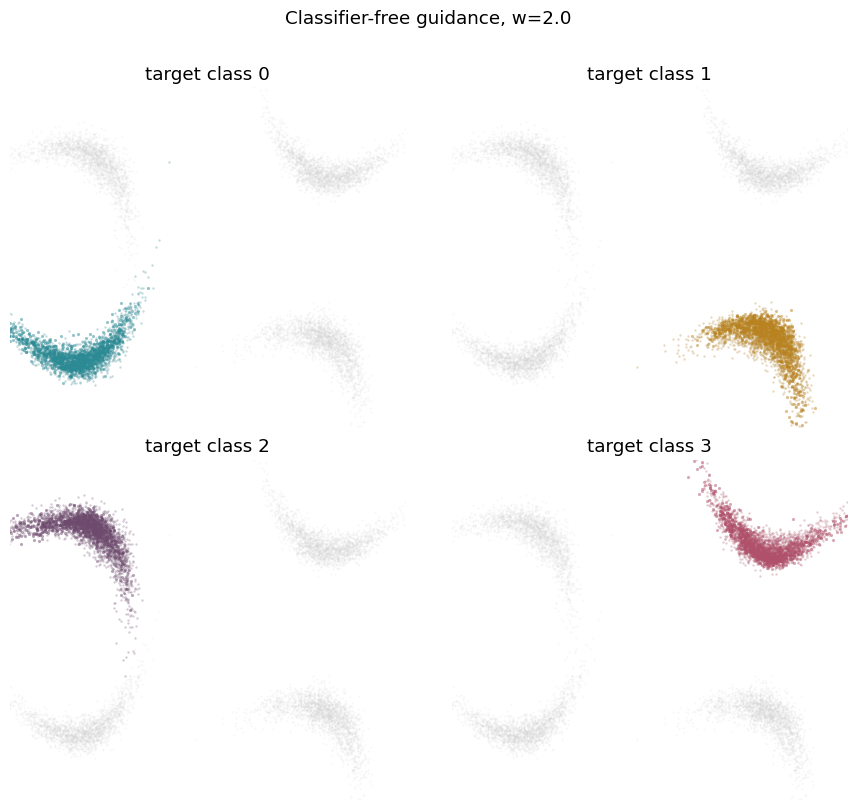

In [58]:
def cond_eps(x_t, t, target=None):
    n = len(x_t)
    sqrt_ab = np.full(n, np.sqrt(ab_t[t - 1])); sqrt_1mab = np.full(n, np.sqrt(1.0 - ab_t[t - 1]))
    onehot = np.zeros((n, 4))
    if target is not None: onehot[:, int(target)] = 1.0
    feats = np.column_stack([x_t, np.full(n, t / T), sqrt_ab, sqrt_1mab, onehot])
    cond_denoiser.eval()
    with torch.no_grad():
        return cond_denoiser(std_cfg(torch.tensor(feats, dtype=torch.float32, device=device))).cpu().numpy()

def cfg_chain(n_samples=900, target=0, w=2.0, rng=None):
    rng = rng or np.random.default_rng()
    x_t = rng.normal(size=(n_samples, 2))
    for t in range(T, 0, -1):
        eps_u = cond_eps(x_t, t, target=None)
        eps_hat = eps_u + w * (cond_eps(x_t, t, target=target) - eps_u)     # guided noise
        sqrt_ab = np.sqrt(ab_t[t - 1]); sqrt_1mab = np.sqrt(1.0 - ab_t[t - 1])
        x0_hat = (x_t - sqrt_1mab * eps_hat) / sqrt_ab
        c1, c2, var = posterior_coefficients(t)
        mean = c1 * x_t + c2 * x0_hat
        x_t = mean if t == 1 else mean + np.sqrt(var) * rng.normal(size=x_t.shape)
    return x_t

def plot_cfg(n_per_class=900, w=2.0):
    fig, axes = plt.subplots(2, 2, figsize=(9, 8), sharex=True, sharey=True); axes = axes.ravel()
    for y, ax in enumerate(axes):
        g = cfg_chain(int(n_per_class), target=y, w=w, rng=rng)
        ax.scatter(x0[:, 0], x0[:, 1], s=2, color="0.82", alpha=0.18, linewidths=0)
        ax.scatter(x0[labels == y, 0], x0[labels == y, 1], s=3, color=PAL[y], alpha=0.25, linewidths=0)
        ax.scatter(g[:, 0], g[:, 1], s=5, color=PAL[y], alpha=0.5, linewidths=0)
        ax.set_title(f"target class {y}"); ax.set_aspect("equal"); ax.set_xlim(-5.8, 5.8); ax.set_ylim(-5, 5); ax.axis("off")
    fig.suptitle(f"Classifier-free guidance, w={w}", y=1.01); plt.tight_layout(); plt.show()

plot_cfg(w=2.0)
if HAS_WIDGETS:
    display(widgets.interact(plot_cfg,
        n_per_class=widgets.IntSlider(value=900, min=200, max=2000, step=100),
        w=widgets.FloatSlider(value=2.0, min=0.0, max=6.0, step=0.25)))


## How this maps to the rest of the course

This toy contains the whole DDPM story, in a space where every step is visible:

- the **forward process** is fixed and Gaussian, and we can jump to any level in closed form;
- the **exact posterior** $q(x_{t-1}\mid x_t,x_0)$ is a clean bridge, available only because it knows $x_0$;
- a **learned denoiser** predicts the noise, which gives both $\hat x_0$ and the **score** $-\varepsilon_\theta/\sqrt{1-\bar\alpha_t}$, so noise-prediction, $x_0$-prediction, and score are one object;
- the **learned reverse chain** plugs $\hat x_0$ into the posterior mean and walks noise back to data;
- **guidance** steers the result, either with a separate classifier or, more cheaply, classifier-free.

Parts 1–2 repeat exactly this on image sprites (DDPM, then conditioning); Part 3 swaps in DDIM for fast sampling; Part 4 moves the whole thing into a learned latent space and connects it to Stable Diffusion. The equations never change, only the space they act on.
